In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import norm
import sys
import os
import xarray as xr
import glob
import pandas as pd
from scipy.interpolate import interpn, griddata
from IPython.display import Image, display

sys.path.append(os.path.abspath("/home/hana/Documents/dalhousie/training/CREATE/Data_Module/codes/eof-analysis"))
from eofs import eofs

## Background {-}
From Shaw and Stastna (2019), the error map $\epsilon_D(t_j)$ of an EOF reconstruction with $D$ modes at time $t_j$ is calculated as
$$\epsilon_D(t_j) = \left| \sum_{k=D+1}^{\text{min}\{M,N\}} a_k(t_j)\phi_k \right|_{\infty}$$

Here, $a_k(t_j)$ are time-dependent coefficients and $\phi_k$ are the EOFs.

I will attempt to calculate this product for a multi-year mooring time series at the Fisheries and Oceans Canada HAK1 station to see if there are any jumps in EOF error indicating possible time periods of interest. The HAK1 mooring station is located off the coast of BC in about 140 m of water and was occupied between 2016 and 2022. The mooring line typically had two Acoustic Doppler Current Profilers (ADCPs) at around 30m and 130 m depth and was replaced once per year in summer. In the map below, the green circle indicates the position of this station.

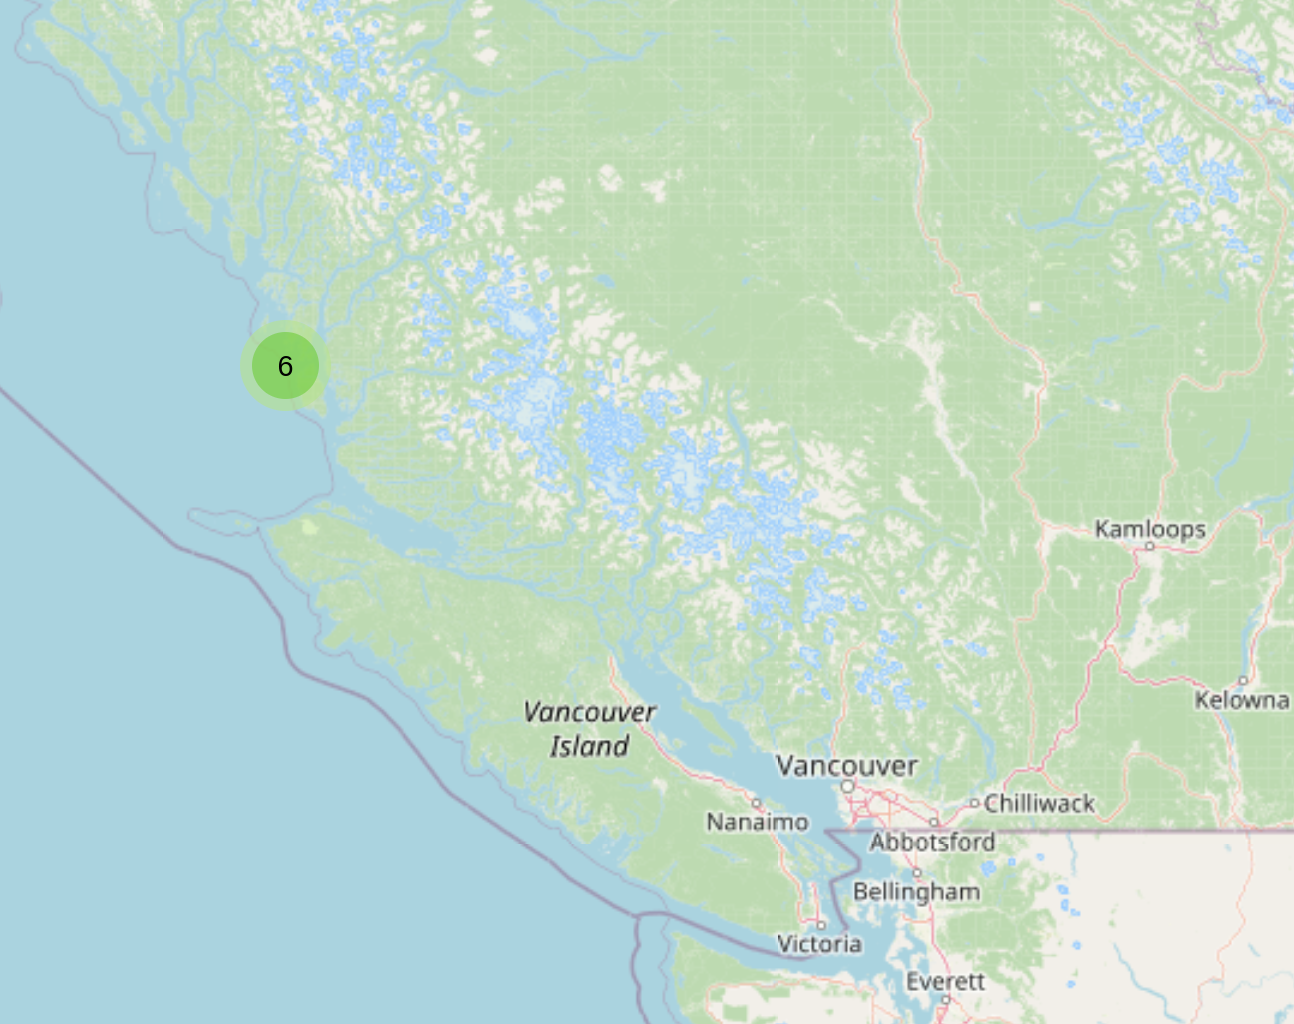

In [2]:
display(Image(filename='hak1_mooring_map_wp.png', width=500))

Image credit: https://www.waterproperties.ca/

## Preparing the data {-}
I have downloaded the data for the lower ADCP across the full occupation of the station. Since the instrument is not moored at the exact same water depth each time, the velocity bins need to be interpolated to the same depths for each deployment. The data are expected to contain NaNs, which are not handled by single value decomposition (SVD). These will need to be removed or filled by interpolation. 

First, the data will be read in, interpolated to common depths, and concatenated to produce a single time series.

In [3]:
haklist = glob.glob('/home/hana/Documents/dalhousie/training/CREATE/Data_Module/data/hak1*.nc')
haklist.sort()

# hak = xr.open_dataset(haklist[0])  # , data_vars='all', join='outer')

In [4]:
dt = np.array([])
# Don't go all the way to surface due to backscatter increases
bin_depths = np.arange(132, 0, -2)
# Track deployment number
deploy_num = np.array([])
u = None

t0 = pd.to_datetime('2016-01-01')

for fi in haklist:
    print(os.path.basename(fi))
    dat = xr.open_dataset(fi)
    # print(dat.time.data[:5])
    # print(dat.time.data[-5:])
    # Get timedelta in seconds for interpolation
    dt_fi = (pd.to_datetime(dat.time.data) - t0).total_seconds()
    bins_fi = dat.instrument_depth.data - dat.distance.data
    points = (bins_fi, dt_fi)  # np.meshgrid(*(bins_fi, dt_fi), indexing='ij')
    values = dat.LCEWAP01.data
    target = np.meshgrid(*(bin_depths, dt_fi), indexing='ij')
    u_fi = interpn(
        points, values, target, 
        bounds_error=False,
        fill_value=np.nan
    )
    if u is None:
        u = u_fi
    else:
        u = np.concatenate((u, u_fi), axis=1)
    dt = np.concatenate((dt, dt_fi))
    deploy_num = np.concatenate(
        (deploy_num, np.repeat(dat.deployment_number, len(dt_fi)))
    )

hak1_20160706_20170708_0137m_L1.adcp.nc
hak1_20170708_20180821_0131m_L1.adcp.nc
hak1_20180820_20190804_0134m_L1.adcp.nc
hak1_20190804_20200722_0128m_L1.adcp.nc
hak1_20200721_20210605_0135m_L1.adcp.nc
hak1_20210604_20220718_0132m_L1.adcp.nc


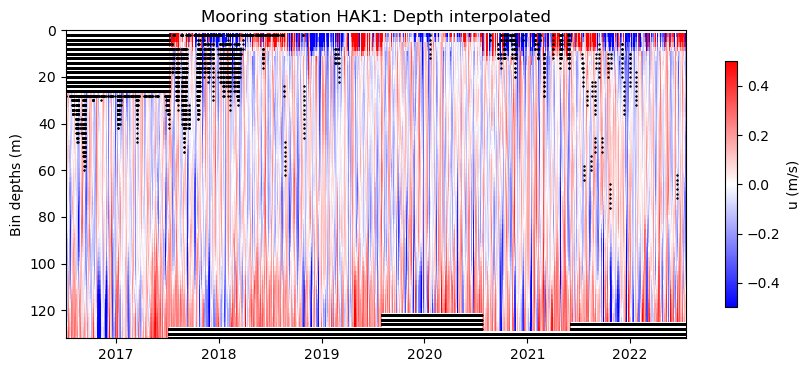

In [5]:
datetime = pd.to_datetime(dt, unit='s', origin=t0)
vlim = 0.5  # color bar limit
fig, ax = plt.subplots(figsize=(10,4))
c1 = ax.pcolormesh(
    datetime, bin_depths, u,
    cmap='bwr', shading='nearest',
    vmin=-vlim, vmax=vlim
)
plt.colorbar(c1, label='u (m/s)', shrink=0.8)

yy, xx = np.meshgrid(*(bin_depths, datetime), indexing='ij')
mask_na = np.isnan(u)
ax.plot(xx[mask_na], yy[mask_na], 'k.', markersize=1)

ax.set_ylim(132, 0)
ax.set_ylabel('Bin depths (m)')
ax.set_title('Mooring station HAK1: Depth interpolated')
plt.show()

The eastward velocity component is plotted above with NaNs shown in black. Time gaps during mooring replacements don't show up in the nans because there are no time stamps during those gaps. The plot shows that the bins in the first deployment only went to about 30 m, while the others had longer ranges and were located slightly shallower in the water column. 

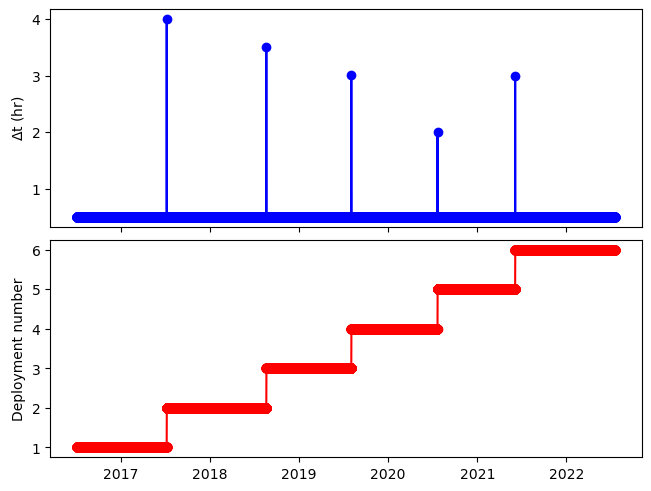

In [6]:
fig, axs = plt.subplots(nrows=2, sharex=True, layout='constrained', figsize=(6.4, 3))
axs[0].plot(datetime[1:], np.diff(dt)/3600, 'bo-')
axs[0].set_ylabel(r'$\Delta$t (hr)')
axs[1].plot(datetime[1:], deploy_num[1:], 'ro-')
axs[1].set_ylabel('Deployment number')
plt.show()

The above plot confirms that time jumps correspond to mooring line replacements (new deployments). Now I interpolate the unstructured non-NaN data through the time gaps and NaN gaps to get uniformly gridded velocity data with no NaNs present.

In [7]:
dt_even = np.arange(dt[0], dt[-1] + 1, 1800)
print(len(dt_even), len(dt))

# Limit bins to subsurface 30-120m
bins_lim = bin_depths[
    (bin_depths >= 30) & (bin_depths <= 115)
]

mask_notna = ~np.isnan(u)
yy, xx = np.meshgrid(*(bin_depths, dt), indexing='ij')
target = np.meshgrid(*(bins_lim, dt_even), indexing='ij')

u_even = griddata(
    (yy[mask_notna], xx[mask_notna]), 
    u[mask_notna], target, 
    method='nearest',
    fill_value=np.nan
)

105706 105680


## The error map {-}
Now I can compute the EOFs and the error map.

In [8]:
nt = len(dt_even)
nbin = len(bins_lim)
num_modes = min([nt - 1, nbin - 1])   # 60
# data_nona = np.interp()
lambda_vals, U, coeff, cumul_approx = eofs(u_even, num_modes)

myerrinf = np.zeros(num_modes * nt).reshape(num_modes, nt)
myerr2 = np.zeros(num_modes * nt).reshape(num_modes, nt)

# Remove mean (along time dimension)
data_noav = u_even - u_even.mean(axis=1, keepdims=True)

for ii in range(num_modes):
    myapp = cumul_approx[ii]  # my approximation
    myerrnow = (myapp - data_noav).T  # my error now
    myerrinf[ii, :] = norm(myerrnow, np.inf, axis=1)  # infinity norm of the error
    myerr2[ii, :] = norm(myerrnow, 2, axis=1)  # norm-2 error

In [9]:
# Get indices where new deployment starts
unique, ind = np.unique(deploy_num, return_index=True)

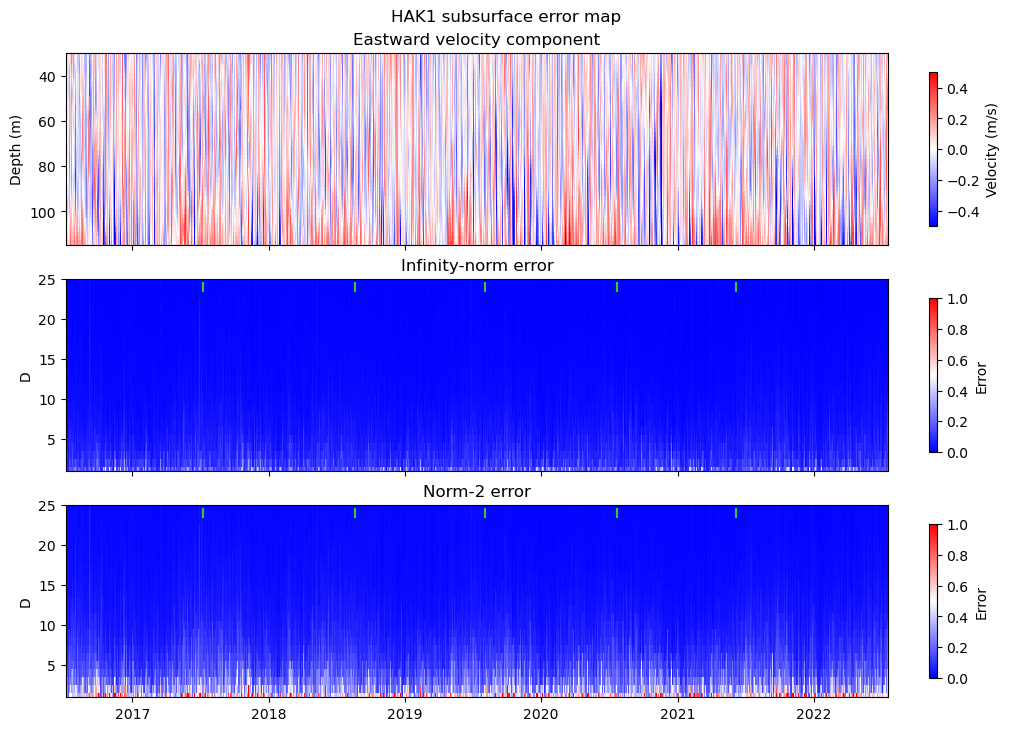

In [10]:
fig, axs = plt.subplots(
    nrows=3, layout='constrained', sharex=True,
    figsize=(10, 7.2)
)

datetime_even = pd.to_datetime(dt_even, unit='s', origin=t0)
vlim = 0.5
c1 = axs[0].pcolormesh(
    datetime_even, bins_lim, u_even,
    cmap='bwr', shading='nearest', 
    vmin=-vlim, vmax=vlim
)
plt.colorbar(c1, shrink=0.8, label='Velocity (m/s)') 
# # Smart formatter and locator
# locator = mdates.AutoDateLocator()
# formatter = mdates.ConciseDateFormatter(locator)
# axs[0].xaxis.set_major_locator(locator)
# axs[0].xaxis.set_major_formatter(formatter)

axs[0].set_ylim(115, 30)
axs[0].set_ylabel('Depth (m)')
axs[0].set_title("Eastward velocity component")

c2 = axs[1].pcolormesh(
    datetime_even, 
    np.arange(1, num_modes + 1),
    myerrinf, vmin=0, vmax=1,
    cmap='bwr', shading='auto'
)
plt.colorbar(c2, shrink=0.8, label='Error')
axs[1].set_ylim(1, 25)
axs[1].set_ylabel('D')
axs[1].set_title('Infinity-norm error')

c3 = axs[2].pcolormesh(
    datetime_even, 
    np.arange(1, num_modes + 1),
    myerr2, vmin=0, vmax=1,
    cmap='bwr', shading='auto'
)
plt.colorbar(c3, shrink=0.8, label='Error')
axs[2].set_ylim(1, 25)
axs[2].set_ylabel('D')
axs[2].set_title('Norm-2 error')

for ii in range(1, 3):
    axs[ii].scatter(
        datetime_even[ind[1:]],
        np.repeat(24, len(ind) - 1),
        marker='|', color='limegreen',
        s=50
    )

plt.suptitle('HAK1 subsurface error map')
plt.show()

The input data, the infinity norm error, and the norm-2 error are plotted above. The lime green ticks indicate when the mooring lines are replaced. 

The infinity-norm error is generally low, with the first couple of modes accounting for much of the variance in the combined data set. This is expected, since tides produce much of the variability in current velocity and these are processes with well-defined periods. Error in the first few modes seems to increase towards the end of the calendar year which may be from winter storm mixing or upwelling. 

The norm-2 error has larger magnitude and thus better shows variation in error. This error map has a distinct sinusoid shape over the time series. Error in modes 5-10 seems to maximize in the middle of the calendar year, rather than towards the end of the year. Physically, I'm not sure why this is. 2016 and 2017 show faint but noticeable spikes into mode 20, which are not from the mooring replacements since the timing doesn't align.

The error spike in the second half of 2021 that I shared earlier is gone, so it must have been a coding mistake that caused it.

## Reconstructions {-}
The last part of this exercise uses material from the introduction to EOFs. The first three reconstructions are plotted below.

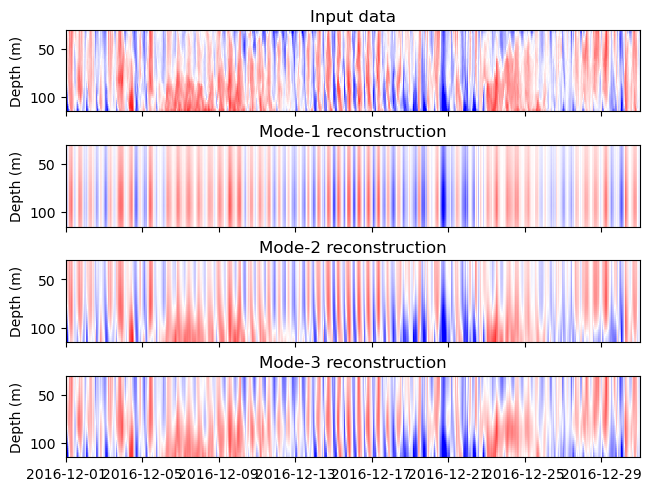

In [11]:
modes = 3
fig, axs = plt.subplots(nrows=modes+1, sharex=True, layout='constrained')

m = 0
axs[m].pcolormesh(
    datetime_even, bins_lim,
    u_even, cmap='bwr', shading='nearest',
    vmin=-vlim, vmax=vlim
)
axs[m].set_ylabel('Depth (m)')
axs[m].set_ylim(115, 30)
axs[m].set_title('Eastward velocity component')

for m in range(1, modes + 1):
    axs[m].pcolormesh(
        datetime_even, bins_lim,
        cumul_approx[m - 1],
        cmap='bwr', shading='nearest',
        vmin=-vlim, vmax=vlim
    )
    axs[m].set_ylabel('Depth (m)')
    axs[m].set_ylim(115, 30)
    # axs[m].set_xlim(pd.to_datetime('2016-12-01'), pd.to_datetime('2016-12-31'))
    axs[m].set_title(f'Mode-{m} reconstruction')

# plt.savefig('adcp_hak1_reconstruction.png')

Visually, the mode-2 reconstruction does a decent job of matching the input data. Finally, the EOF variance spectrum is plotted below.

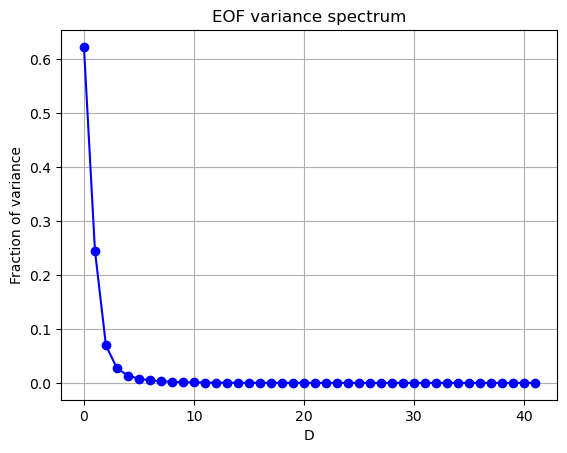

In [12]:
# Eigenvalue spectrum
plt.plot(lambda_vals / lambda_vals.sum(), "bo-")
plt.xlabel("D")
plt.ylabel("Fraction of variance")
plt.title("EOF variance spectrum")
plt.grid(True)

In [13]:
print(sum((lambda_vals / lambda_vals.sum())[:2]))

0.8670344498064417


The EOF variance spectrum shows that the first two modes capture about 87% of the variance in the data set.

## Baroclinic modes {-}
I will use the EOF reconstructions to visualize barotropic and baroclinic components of the flow. Barotropic flow is flow parallel to surfaces of constant density (isopycnals), while baroclinic flow crosses isopycnals. 

I read the first four subsections of the internal waves chapter from Cushman-Roisin and Beckers (2011) to gain some more background on these components, which are also known as vertical modes. Assuming constant depth and no surface waves, vertical modes can be described mathematically by the following second-order differential equation,

$$\frac{\text{d}^2 W}{\text{d}z^2} + \frac{(N^2 - \omega^2 )}{gh^{(j)}}W = 0$$

where $W(z)$ is the vertical mode, $N^2=-\frac{g}{\rho_0}\frac{\partial \bar{\rho}}{\partial z}$ is the buoyancy frequency, $\omega$ is the wave frequency, and $h^{(j)}$ is the equivalent depth.

The dispersion relation in this scenario is
\begin{align}
    \omega^2 = f^2 + gh^{(j)} \left(k_x^2 + k_y^2 \right)
\end{align}

which can be substituted into the first equation to yield

\begin{align}
    \frac{\text{d}^2 W}{\text{d}z^2} + \left(k_x^2 + k_y^2 \right) \frac{(N^2(z) - \omega^2 )}{\omega^2 - f^2}W = 0
\end{align}

Values of $\omega$ for which $W(z) \neq 0$ are eigenvalues and $W(z)$ are vertical modes. 

I will start by calculating the individual, not cumulative, mode reconstructions for the first three modes.

In [14]:
# First 3 mode components
M, N = u_even.shape
mode_comp = np.zeros((3, M, N))

for kk in range(3):
    mode_comp[kk] = U[:, kk:kk+1] @ coeff[kk:kk+1, :]

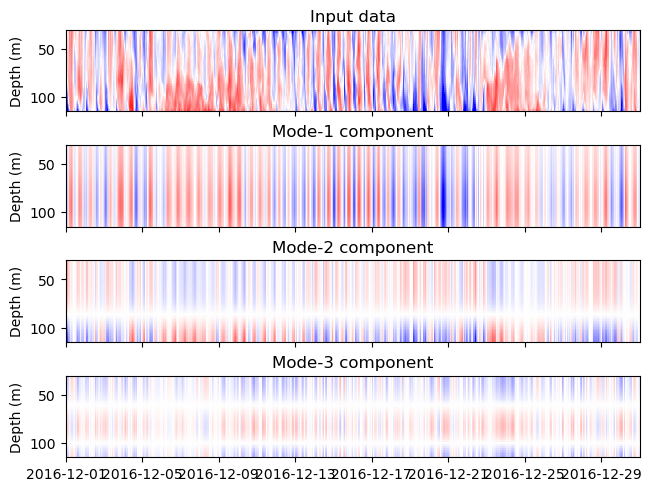

In [41]:
fig, axs = plt.subplots(nrows=modes+1, sharex=True, layout='constrained')

m = 0
axs[m].pcolormesh(
    datetime_even, bins_lim,
    u_even, cmap='bwr', shading='nearest',
    vmin=-vlim, vmax=vlim
)
axs[m].set_ylabel('Depth (m)')
axs[m].set_ylim(115, 30)
axs[m].set_title('Eastward velocity component')

for m in range(1, modes + 1):
    axs[m].pcolormesh(
        datetime_even, bins_lim,
        mode_comp[m - 1],
        cmap='bwr', shading='nearest',
        vmin=-vlim, vmax=vlim
    )
    axs[m].set_ylabel('Depth (m)')
    axs[m].set_ylim(115, 30)
    # axs[m].set_xlim(pd.to_datetime('2016-12-01'), pd.to_datetime('2016-12-31'))
    axs[m].set_title(f'Mode-{m} component')

# plt.show()
plt.savefig('hak1_mode_decomp_pcolor.png')

The individual contributions of modes 1-3 to the EOF reconstruction are plotted above for December 2016. The mode-1 component is the barotropic mode. Modes 2 and 3 are the first two baroclinic modes. The eastward velocities in the barotropic mode are constant over depth, while the baroclinic modes contain the number of sign reversals in the water column equal to the baroclinic mode number.

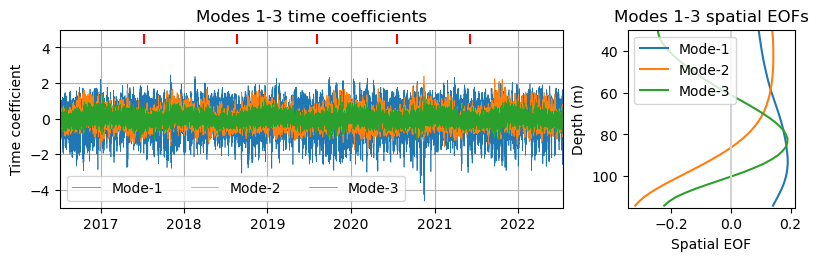

In [43]:
# Time series of coefficients
fig, axs = plt.subplots(
    ncols=2, figsize=(8, 2.5), 
    width_ratios=[3, 1],
    layout='constrained'
)

for ii in range(1, 4):
    axs[0].plot(
        datetime_even, coeff[ii - 1, :],
        label=f'Mode-{ii}',
        lw=0.5
    )

axs[0].scatter(
    datetime_even[ind[1:]],
    np.repeat(4.5, len(ind) - 1),
    marker='|', color='r',
    s=50
)

axs[0].legend(loc='lower left', ncols=3)
axs[0].set_xlim(datetime_even[0], datetime_even[-1])
axs[0].set_ylim(-5, 5)
axs[0].grid()
axs[0].set_ylabel('Time coefficient')
axs[0].set_title('Modes 1-3 time coefficients')

# 'Modes 1-3 spatial EOFs'
for ii in range(1, 4):
    axs[1].plot(
        U[:, ii - 1], bins_lim, 
        label=f'Mode-{ii}'
    )

axs[1].legend(loc='upper left')
# axs[1].grid()
axs[1].axvline(x=0, c='lightgrey')
axs[1].set_ylim(115, 30)
axs[1].set_xlabel('Spatial EOF')
axs[1].set_ylabel('Depth (m)')
axs[1].set_title('Modes 1-3 spatial EOFs')
# plt.show()
plt.savefig('hak1_time-coeff_spatial_eof.png')

The time coefficients for modes 1-3 are plotted above. Red ticks indicate when the mooring was replaced. The magnitude of the coefficients seems to decrease with increasing mode. All coefficent time series seem to follow a sinusoidal shape and have zero mean. Of note is a spike in the mode-1 coefficients at the end of 2020.

The spatial EOFs are also plotted for the first three modes. The mode-1 EOF does not cross zero, while the modes 2 and 3 EOFs cross zero one and two times, respectively.

## Applications to fish detection in ADCP data
Freitag et al. (1993) used EOFs to process moored downward-looking ADCP data collected in the tropical Pacific ocean. Large pelagic fishes, such as tuna, have been known to take interest in subsurface moorings, but acoustic pings off of them can bias the velocity data. A real-time correction algorithm was not demonstrated to fix this bias as its success was limited to cases where only one or two of the four ADCP beams were affected. The authors implemented a delayed-mode correction that merges the ADCP speeds with speed data collected by mechanical current meters on the same mooring line. In this correction, EOF analysis is performed on the difference in speed between the current meters and the ADCPs, and the resulting eigenvectors are interpolated using cubic splines to the ADCP bin depths and extrapolated to 0 m/s at the sea floor. The modes 1-3 speed difference time series were used as the correction coefficients for the ADCP data. The standard deviation of speed differences was shown to have decreased after the correction.

## References {-}
Cushman-Roisin, B., Beckers, J.-M., 2011. Internal Waves, in: International Geophysics. Elsevier, pp. 395–424. https://doi.org/10.1016/B978-0-12-088759-0.00013-4

Freitag, H.P., Plimpton, P.E., McPhaden, M.J., 1993. Evaluation of an ADCP fish-bias rejection algorithm, in: Proceedings of OCEANS ’93. Presented at the OCEANS ’93, pp. II394-II397 vol.2. https://doi.org/10.1109/OCEANS.1993.326127

Shaw, J., Stastna, M., 2019. Feature identification in time-indexed model output. PLOS ONE 14, e0225439. https://doi.org/10.1371/journal.pone.0225439